# Backpropagation algorithm

In [1]:
# Check for all needed packages
import time

import numpy
import matplotlib
import mnists
# In case of ImportError, install them to the running kernel with
# %pip install numpy matplotlib mnists
# or the the runtime container with:
# !pip install numpy matplotlib mnists
# (In case of the latter, remember to restart the kernel!)

# Tested in Python 3.14.3 with:
# numpy==2.4.3
# matplotlib==3.10.8
# mnists==0.4.1

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1234)

try:
    import mkl

    mkl.set_num_threads(2)
except ImportError:
    print(
        "Intel Math Kernel Library (MKL) does not always work on every machine. "
        "Continuing without `mkl`."
    )

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

Intel Math Kernel Library (MKL) does not always work on every machine. Continuing without `mkl`.


### Handy utility functions

In [3]:
def append_ones(matrix: np.ndarray) -> np.ndarray:
    """
    Appends a column of ones to the right side of a 2D matrix.
    """
    return np.concatenate(
        (matrix, np.ones((matrix.shape[0], 1), dtype=np.float32)), axis=1
    )


def zeros(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of zeros with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. zeros(3, 4) creates a (3, 4) array.
    """
    return np.zeros(shape=tuple(dims), dtype=np.float32)


def ones(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of ones with the given shape.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. ones(3, 4) creates a (3, 4) array.
    """
    return np.ones(shape=tuple(dims), dtype=np.float32)


def rand(*dims: int) -> np.ndarray:
    """
    Creates a NumPy array of random values sampled from a uniform [0, 1) distribution.

    Args:
        *dims:  Variable number of integers defining the shape of the array.
                E.g. rand(3, 4) creates a (3, 4) array.
    """
    return np.random.rand(*dims).astype(np.float32)


def chunks(seq: list, size: int) -> tuple[np.ndarray]:
    """
    Splits a sequence into consecutive chunks of a given size.

    The last chunk may be smaller than `size` if the sequence length
    is not evenly divisible.

    Args:
        seq:  The input sequence (e.g. list or other sliceable) to split.
        size: The maximum number of elements in each chunk.

    Returns:
        Successive sub-sequences of length `size` (or less for the final chunk).
    """
    return tuple([seq[pos : (pos + size)] for pos in range(0, len(seq), size)])


def as_matrix(vector: np.ndarray) -> np.ndarray:
    """Reshape 1D vector to column matrix."""
    return np.reshape(vector, (-1, 1))


def one_hot_encode(labels: np.ndarray) -> np.ndarray:
    """Convert integer labels to one-hot encoded matrix."""
    (n_samples,) = labels.shape
    n_classes = np.max(labels) + 1

    one_hot = np.zeros((n_samples, n_classes), dtype=np.float32)
    one_hot[np.arange(n_samples), labels] = 1
    return one_hot


def arrange_tiles_img(examples: np.ndarray) -> np.ndarray:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]

    space_between_tiles = 2
    img_matrix = np.empty(
        shape=(
            rows_count * (tile_height + space_between_tiles) - space_between_tiles,
            cols_count * (tile_width + space_between_tiles) - space_between_tiles,
        )
    )
    img_matrix.fill(np.nan)

    for r in range(rows_count):
        for c in range(cols_count):
            x_0 = r * (tile_height + space_between_tiles)
            y_0 = c * (tile_width + space_between_tiles)
            img_matrix[x_0 : x_0 + tile_height, y_0 : y_0 + tile_width] = examples[r, c]

    return img_matrix


def preview_tiles(examples: np.ndarray) -> np.ndarray:
    """Previews the arrange tiles"""
    img = arrange_tiles_img(examples)
    plt.matshow(img, cmap="gray", interpolation="none")
    plt.axis("off")
    plt.show()

# MNIST dataset

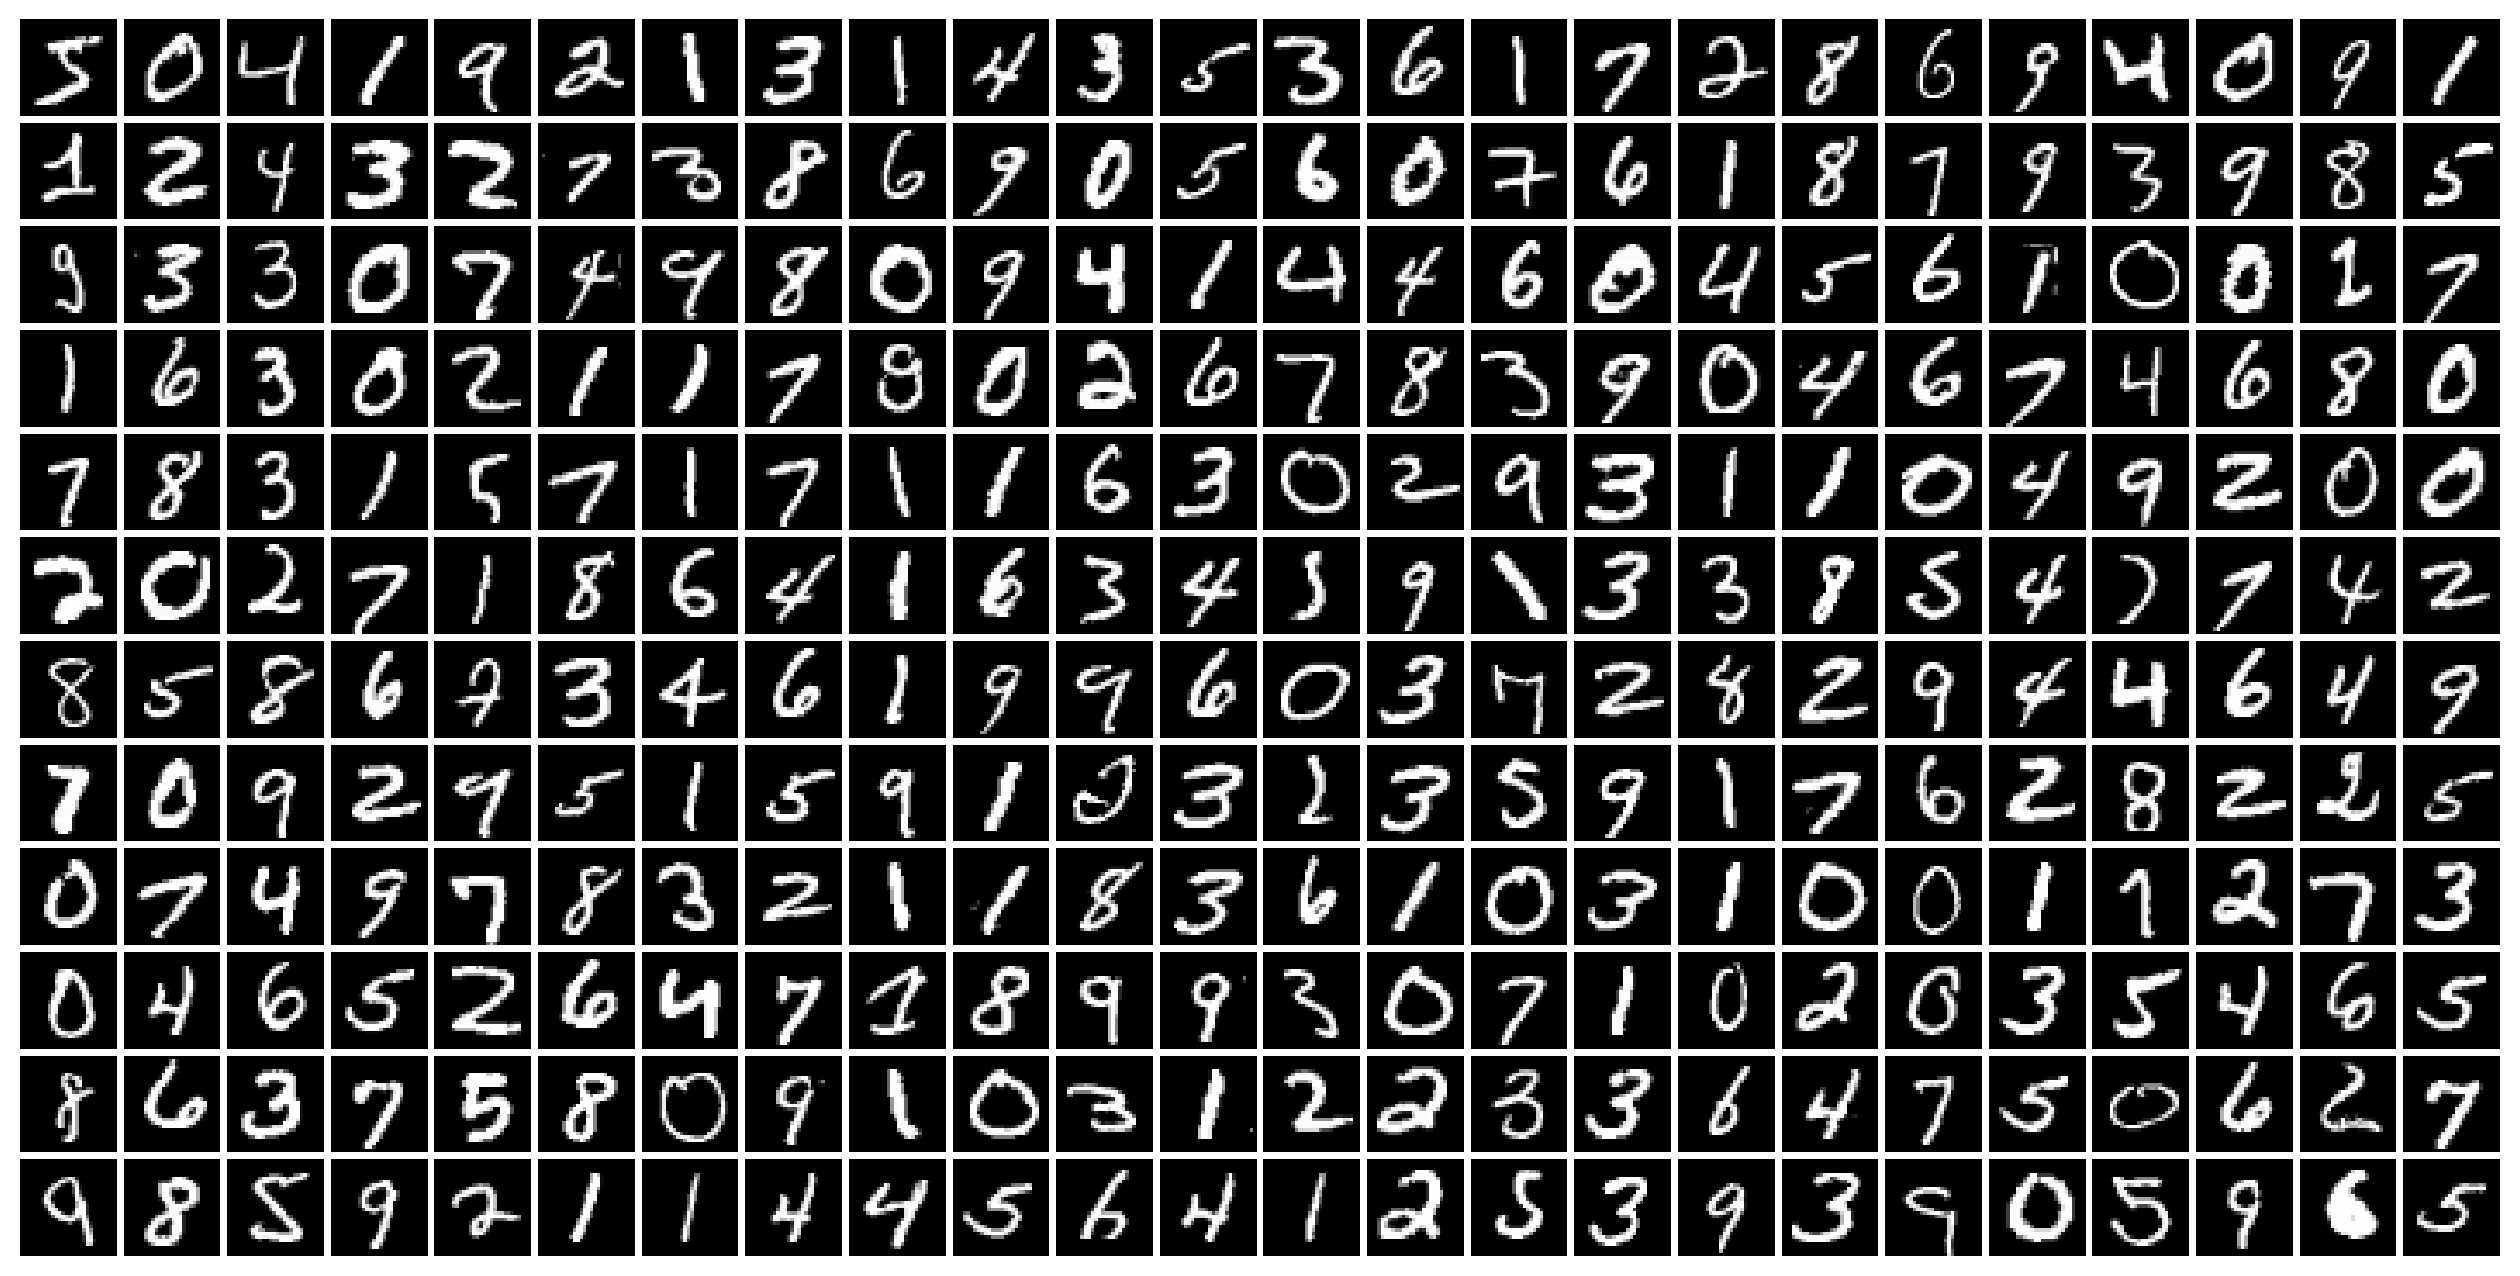

In [4]:
from mnists import MNIST

mnist = MNIST()

PREVIEW_N_ROWS = 12
PREVIEW_N_COLS = 24
TILE_DIM = 28  # [px]


def create_mnist_digits(n_rows: int, n_cols: int, tile_dim: int) -> np.ndarray:
    shape = (n_rows, n_cols, tile_dim, tile_dim)
    return np.reshape(mnist.train_images()[: 12 * 24], shape=shape)


mnist_digits = create_mnist_digits(PREVIEW_N_ROWS, PREVIEW_N_COLS, TILE_DIM)

preview_tiles(mnist_digits)

# Backpropagation algorithm

In [5]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def sigmoid_derivative(x: np.ndarray) -> np.ndarray:
    s = sigmoid(x)
    return s * (1.0 - s)


class Layer:
    def __init__(
        self,
        visible_size: int,
        hidden_size: int,
        activation_fun: callable[np.ndarray],
        d_activation_fun: callable[np.ndarray],
        learning_rate: float,
        momentum: float,
    ):
        self.visible_size = visible_size
        self.hidden_size = hidden_size

        self.activation_fun = activation_fun
        self.d_activation_fun = d_activation_fun

        self.learning_rate = learning_rate
        self.momentum = momentum

        self.reset()

    def reset(self):
        self.W = np.random.normal(
            scale=0.01, size=(self.visible_size + 1, self.hidden_size)
        ).astype(np.float32)
        self.W[-1, :] = 0.0

        self.activations = None
        self.d_activations = None
        self.deltas = None

        self.M = zeros(self.visible_size + 1, self.hidden_size)

In [6]:
from typing import TypeAlias

MLP: TypeAlias = list[Layer]

### Softmax activation

Implement the softmax activation function. Remember that naive sotmax implementation is numerically unstable: the numerator and the denominator may overflow. Make sure that your implementation has no overflow issues.

In [ ]:
def softmax(x: np.ndarray) -> np.ndarray:
    # Remember, that the input is a batch of samples!
    # Tip for stability: normalize the batch by its max value
    # Tip 2: use as_matrix() helper function

    # TODO implement
    raise Exception("Softmax activation function is not implemented!")

### Forward pass

Calculate the total input to the neurons. Then calculate the activations (remember to add *ones* as the last column). Store the result in `layer.activations`.

##### Computing derivatives of activation function

If `compute_derivatives` is set to `True`, we also need to compute the derivatives of the activation function and store them in `layer.d_activations`. We **do not** need to add *ones column* to the derivatives matrix! *Ones* are only needed in the activations matrix, where they are used to add biases to the total input of neurons in the next hidden layer.


In [ ]:
def forward_pass(mlp: MLP, batch: np.ndarray, compute_derivatives: bool) -> np.ndarray:
    visible = batch

    for layer_idx, layer in enumerate(mlp):
        # TODO implement
        raise Exception("Compute layer activations here!")
        # z = ???
        # layer.activations = ???

        if compute_derivatives and (layer_idx < len(mlp) - 1):
            # TODO implement
            raise Exception(
                "Remember about the derivatives of the activation function!"
            )
            # layer.d_activations = ???

        visible = layer.activations

    return visible[:, :-1]

### Error backpropagation

Fist, we need to calculate the deltas in `prev_layer`. To calculate them we use:
 - deltas and weights from `layer`,
 - derivatives of the activation function from `prev_layer`.
 
Once *deltas* are calculated, we can use them to compute gradients.


In [ ]:
def error_backpropagate(mlp: MLP, batch: np.ndarray) -> None:
    observations_count = batch.shape[0]

    # TODO remove this exception
    raise Exception("Error backpropagation is unimplemented")

    for layer_idx, layer in reversed(list(enumerate(mlp))):
        if layer_idx > 0:
            prev_layer = mlp[layer_idx - 1]
            visible = prev_layer.activations

            # TODO implement prev_layer.deltas
            raise Exception("Calculate the deltas in 'prev_layer'")
            # prev_layer.deltas = ???
        else:
            visible = batch

        # TODO update the momentum values
        raise Exception(
            "Update the momentum matrix with gradient from error backpropagation"
        )
        # layer.M = ???

        layer.W += layer.M

### MLP training

In order to start the back propagation procedure, we need to compute *deltas* in the output layer (that is $\Delta^{\left(y\right)}$). Use network output (from the forward pass) and target labels (stored in `batch_labels`) to calculate the *deltas*. Remember that the output layer is a softmax and that we minimize cross-entropy cost.

In [ ]:
def train_mlp(
    mlp: MLP, dataset: np.ndarray, labels: np.ndarray, batch_size: np.ndarray
) -> None:
    batches_limit = dataset.shape[0] / batch_size

    batched_data = chunks(dataset, batch_size)
    batched_labels = chunks(labels, batch_size)

    for batch_idx, (batch, batch_labels) in enumerate(
        zip(batched_data, batched_labels)
    ):
        # Forward pass: compute activatations and derivatives of activations
        y = forward_pass(mlp, batch, True)

        # TODO implement the deltas for the last layer (i.e. the loss function)
        raise Exception("Delta in the sofmax layer is unimplemented!")
        # mlp[-1].deltas = ???

        # Once softmax deltas are set, we may backpropagate errors
        error_backpropagate(mlp, batch)

        if batch_idx % round(batches_limit / 50) == 0:
            print("#", end="")

# MNIST digits classification

In [ ]:
import time


def classify(mlp: MLP, batch: np.ndarray) -> np.ndarray:
    probabilities = forward_pass(mlp, batch, False)
    return np.argmax(probabilities, axis=1)


def run_training(
    mlp: MLP,
    train_set: np.ndarray,
    train_labels: np.ndarray,
    validation_set: np.ndarray,
    validation_labels: np.ndarray,
    batch_size: int,
    epochs_count: int,
) -> None:

    for epoch in range(epochs_count):
        print("Epoch {}:".format(epoch + 1), end="\t")

        start_time = time.time()
        train_mlp(mlp, train_set, train_labels, batch_size)
        elapsed = time.time() - start_time

        predictions = classify(mlp, validation_set)
        accuracy = (
            100.0 * np.sum(predictions == validation_labels) / predictions.shape[0]
        )
        print("\telapsed: {0:>2.2f}s, accuracy: {1:>2.2f}".format(elapsed, accuracy))

    print("Training finished!")

In [12]:
def draw_layer_filters(layer: Layer) -> None:
    filters = np.reshape(layer.W[:-1, :].T, shape=(8, -1, 28, 28))
    preview_tiles(filters)

In [ ]:
DATASET_SIZE: int = 20000  # 60000 for whole dataset
DIGIT_SIZE: int = 28

VISIBLE_LAYER_SIZE = DIGIT_SIZE * DIGIT_SIZE
HIDDEN_LAYER_SIZE = 256

##### Train set #####

mnist_train_images = mnist.train_images().astype(np.float32) / 255.0
mnist_train_labels = mnist.train_labels()

order = np.random.permutation(len(mnist_train_images))
mnist_train_images = mnist_train_images[order]
mnist_train_labels = mnist_train_labels[order]

mnist_train_images = np.reshape(
    mnist_train_images[:DATASET_SIZE], shape=(DATASET_SIZE, DIGIT_SIZE * DIGIT_SIZE)
)
mnist_train_images = append_ones(mnist_train_images)

mnist_train_labels = mnist_train_labels[:DATASET_SIZE]
mnist_train_labels = one_hot_encode(mnist_train_labels)

##### Test set #####

mnist_test_images = mnist.test_images().astype(np.float32) / 255.0
mnist_test_images = np.reshape(mnist_test_images, shape=(-1, DIGIT_SIZE * DIGIT_SIZE))
mnist_test_images = append_ones(mnist_test_images)

mnist_test_labels = mnist.test_labels()

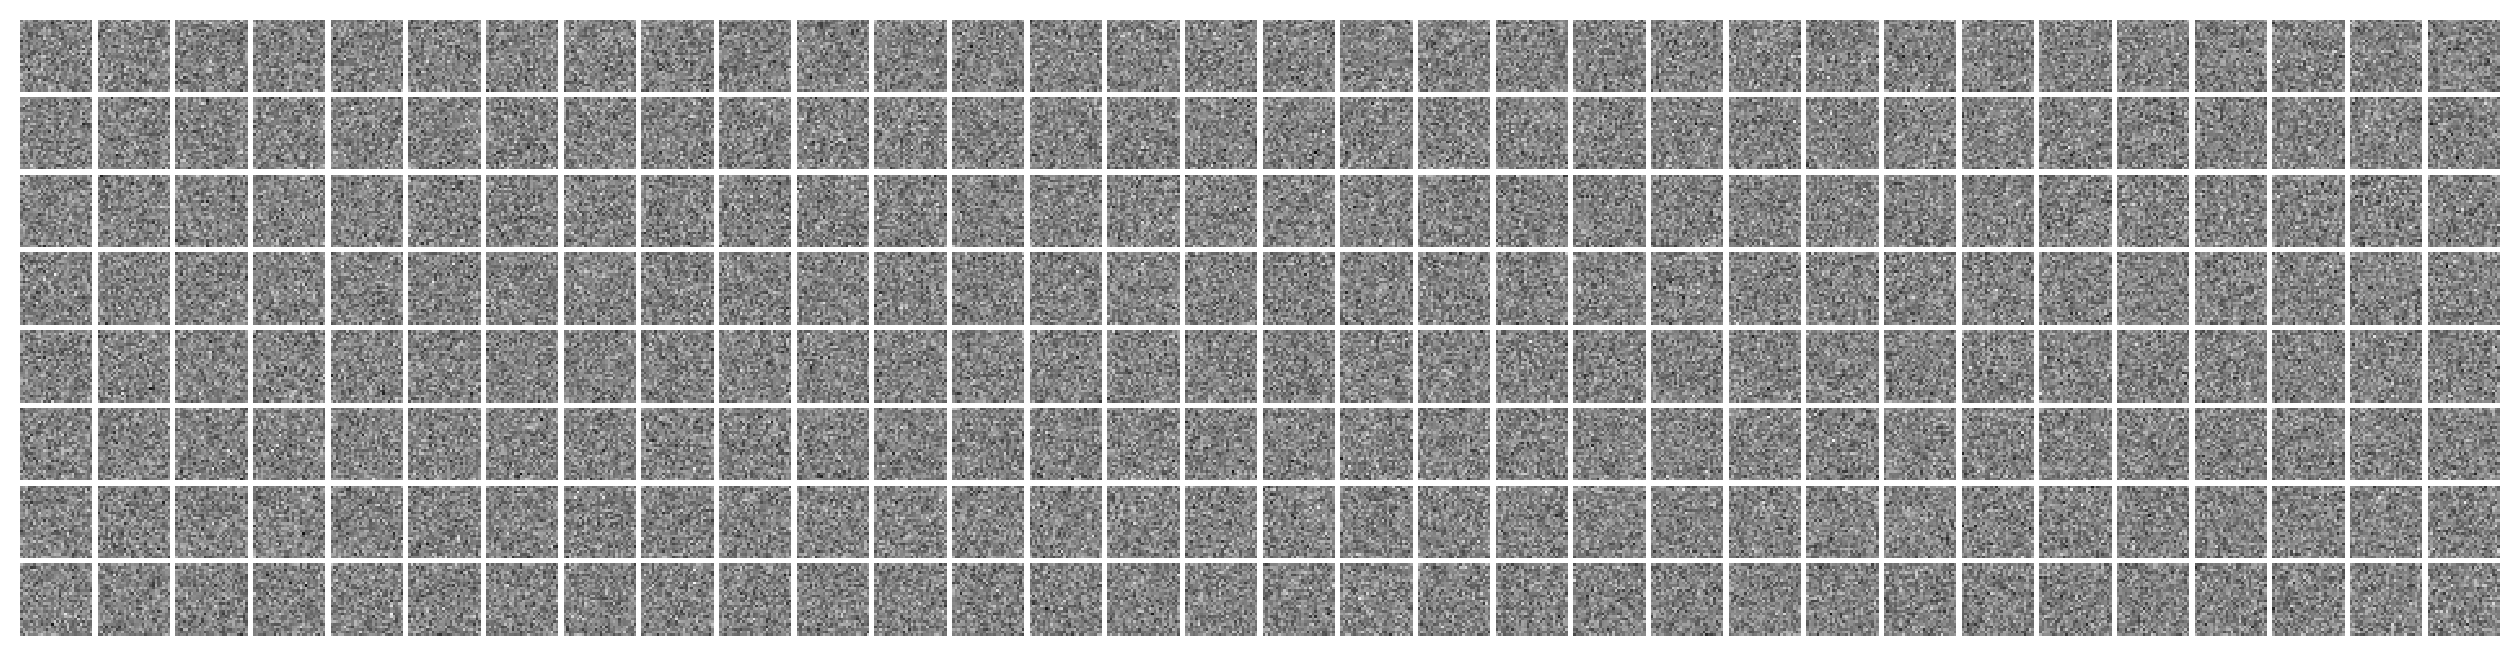

Epoch 1:	#####################################################	elapsed: 1.45s, accuracy: 22.89
Epoch 2:	#####################################################	elapsed: 1.21s, accuracy: 32.39
Epoch 3:	#####################################################	elapsed: 0.86s, accuracy: 35.75
Epoch 4:	#####################################################	elapsed: 1.28s, accuracy: 48.62
Epoch 5:	#####################################################	elapsed: 1.16s, accuracy: 67.83
Epoch 6:	#####################################################	elapsed: 0.85s, accuracy: 84.14
Epoch 7:	#####################################################	elapsed: 0.61s, accuracy: 88.51
Epoch 8:	#####################################################	elapsed: 1.03s, accuracy: 89.98
Epoch 9:	#####################################################	elapsed: 1.89s, accuracy: 90.76
Epoch 10:	#####################################################	elapsed: 0.79s, accuracy: 91.33
Epoch 11:	#######################################

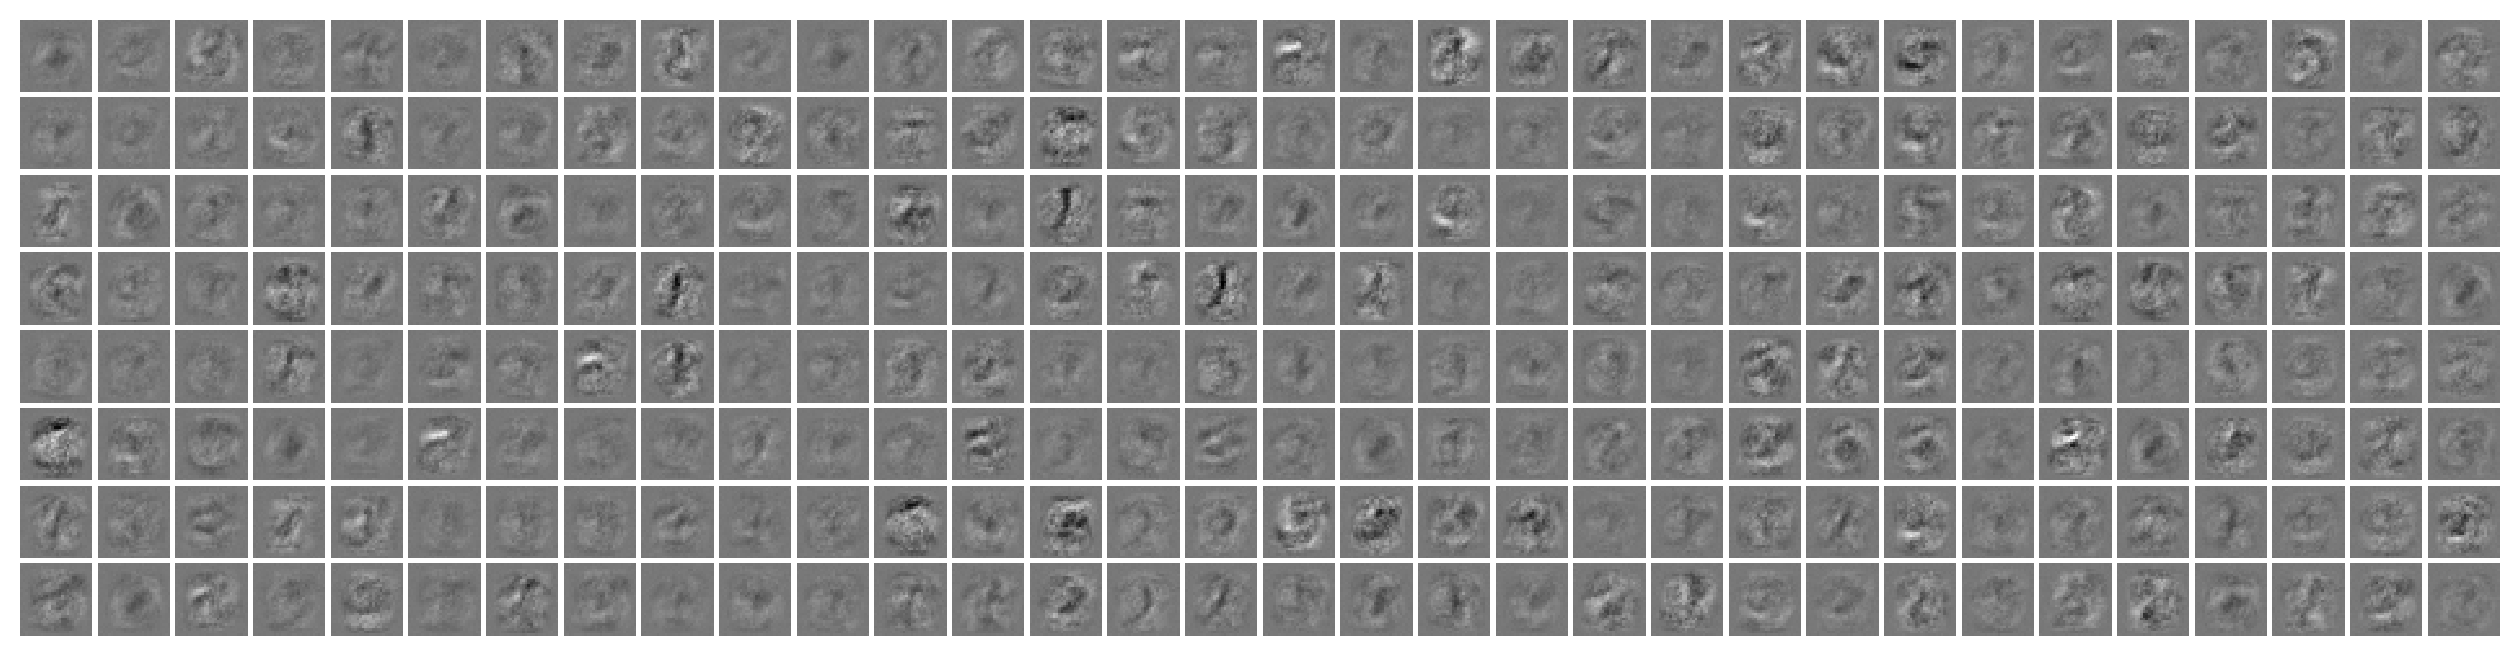

In [14]:
BATCH_SIZE: int = 128
EPOCHS_COUNT: int = 50

LEARNING_RATE: float = 0.1
SOFTMAX_LEARNING_RATE: float = 0.15
MOMENTUM: float = 0.9

mlp: MLP = [
    Layer(
        VISIBLE_LAYER_SIZE,
        HIDDEN_LAYER_SIZE,
        sigmoid,
        sigmoid_derivative,
        LEARNING_RATE,
        MOMENTUM,
    ),
    Layer(
        HIDDEN_LAYER_SIZE,
        HIDDEN_LAYER_SIZE,
        sigmoid,
        sigmoid_derivative,
        LEARNING_RATE,
        MOMENTUM,
    ),
    Layer(HIDDEN_LAYER_SIZE, 10, softmax, None, SOFTMAX_LEARNING_RATE, MOMENTUM),
]

draw_layer_filters(mlp[0])

run_training(
    mlp=mlp,
    train_set=mnist_train_images,
    train_labels=mnist_train_labels,
    validation_set=mnist_test_images,
    validation_labels=mnist_test_labels,
    batch_size=BATCH_SIZE,
    epochs_count=EPOCHS_COUNT,
)

draw_layer_filters(mlp[0])